In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tqdm as tqdm
import joblib as joblib
import importlib as importlib
import scipy as sp
import qutip as qt
from scipy.optimize import minimize

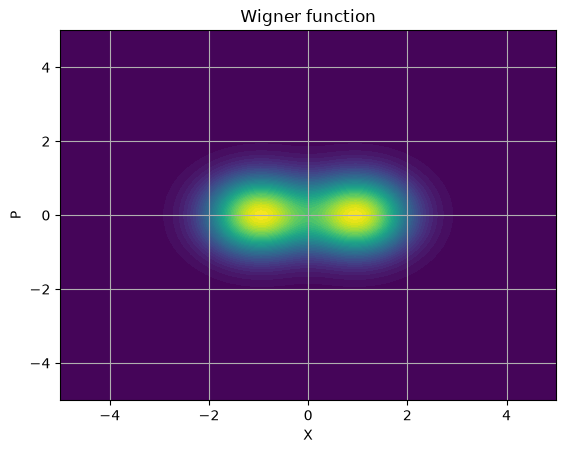

In [3]:
#coherent state from qutip
alpha = 0.7 + 0j
N = 100
coherent_state1 = qt.coherent(N, alpha)
coherent_state2 = qt.coherent(N, -alpha)
#plot in phase space
fig, ax = plt.subplots()
coherent_wigner1 = qt.wigner(coherent_state1, np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
coherent_wigner2 = qt.wigner(coherent_state2, np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
sum_wigner = coherent_wigner1 + coherent_wigner2
ax.contourf(np.linspace(-5, 5, 100), np.linspace(-5, 5, 100), sum_wigner, 50)
ax.set_xlabel('X')
ax.set_ylabel('P')
ax.set_title('Wigner function')
ax.grid()

Minimum error prob
$$
P_H = \cfrac12 \left( 1- \sqrt{1-|\langle\alpha |\beta \rangle|^2} \right)
$$

In [4]:
def min_error_prob(coherent_state1, coherent_state2):
    # Calculate the overlap between the two coherent states
    overlap = np.abs(coherent_state1.overlap(coherent_state2))**2
    # Calculate the minimum error probability using the Helstrom bound
    min_error_prob = 0.5 * (1 - np.sqrt(1 - overlap))
    return min_error_prob
P_H = min_error_prob(coherent_state1, coherent_state2)
print(f'Minimum error probability: {P_H:.4f}')

Minimum error probability: 0.0366


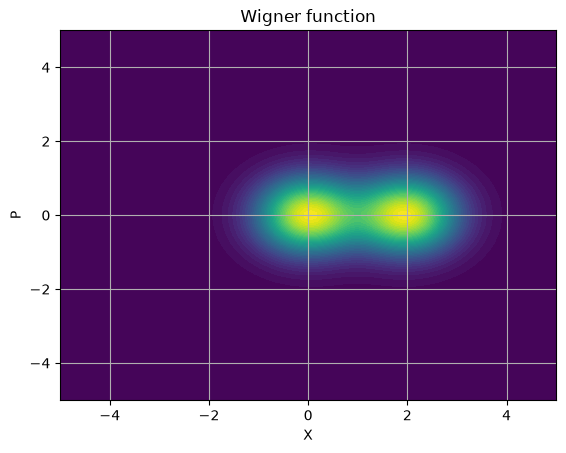

In [5]:
displace_alpha = qt.displace(N, alpha)
coherent_state1_displaced = displace_alpha * coherent_state1
coherent_state2_displaced = displace_alpha * coherent_state2
fig, ax = plt.subplots()
coherent_wigner1 = qt.wigner(coherent_state1_displaced, np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
coherent_wigner2 = qt.wigner(coherent_state2_displaced, np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
sum_wigner = coherent_wigner1 + coherent_wigner2
ax.contourf(np.linspace(-5, 5, 100), np.linspace(-5, 5, 100), sum_wigner, 50)
ax.set_xlabel('X')
ax.set_ylabel('P')
ax.set_title('Wigner function')
ax.grid()


In [6]:
def extract_alpha(coherent_state):
    a = qt.destroy(N)
    extracted_alpha = (coherent_state.dag() * a * coherent_state)
    return extracted_alpha

def kennedy_receiver(coherent1, coherent2, N):
    #extract alpha from coherent state
    alpha1 = extract_alpha(coherent1)
    alpha2 = extract_alpha(coherent2)
    #displace states by -alpha1
    displaced1 = qt.displace(N, -alpha1) * coherent1
    displaced2 = qt.displace(N, -alpha1) * coherent2
    #vacuum state
    vac_projector = qt.fock_dm(N, 0)
    prob_of_zero1 = qt.expect(vac_projector, displaced1)
    prob_of_zero2 = qt.expect(vac_projector, displaced2)
    prob_of_one1 = 1 - prob_of_zero1
    prob_of_one2 = 1 - prob_of_zero2
    #plot the before displacement and after displacement states in phase space
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 5))
    print(type(alpha1))
    maxR = np.max([np.abs(alpha1.real), np.abs(alpha2.real)])
    maxI = np.max([np.abs(alpha1.imag), np.abs(alpha2.imag)])
    plot_ranges_from_alpha = max(maxR, maxI) *3*np.sqrt(2)
    before_wigner1 = qt.wigner(coherent1, np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100), np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100))
    before_wigner2 = qt.wigner(coherent2, np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100), np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100))
    after_wigner1 = qt.wigner(displaced1, np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100), np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100))
    after_wigner2 = qt.wigner(displaced2, np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100), np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100))
    wigner_list = [before_wigner1, before_wigner2, after_wigner1, after_wigner2]
    for ax in [ax1, ax2, ax3, ax4]:
        ax.contourf(np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100), np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100), wigner_list.pop(0), 50)
        ax.set_xlabel('X')
        ax.set_ylabel('P')
        ax.grid()
    ax1.set_title('Before displacement: State 1')
    ax2.set_title('Before displacement: State 2')
    ax3.set_title('After displacement: State 1')
    ax4.set_title('After displacement: State 2')
    print("After displacement:")
    print(f"If state 1 was sent, the probability of detecting a photon is: {prob_of_one1:.4f}")
    print(f"If state 2 was sent, the probability of detecting a photon is: {prob_of_one2:.4f}")



<class 'complex'>
After displacement:
If state 1 was sent, the probability of detecting a photon is: -0.0000
If state 2 was sent, the probability of detecting a photon is: 1.0000


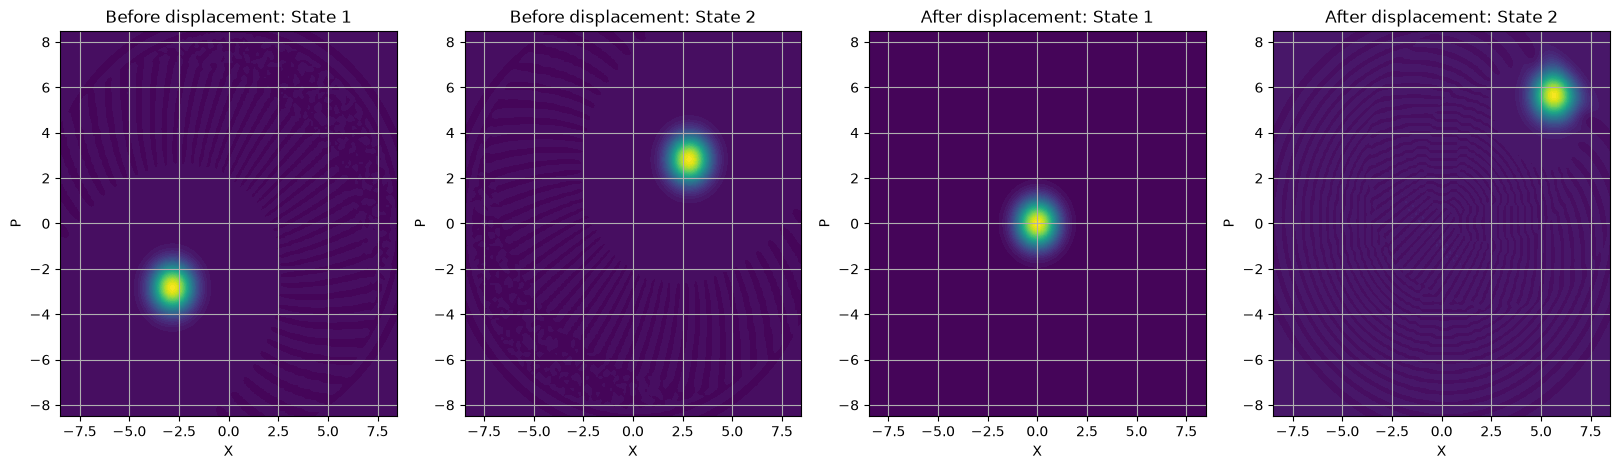

In [7]:
N = 50
alpha1 = -2 - 2j
alpha2 = 2 + 2j
coherent1 = qt.coherent(N, alpha1)
coherent2 = qt.coherent(N, alpha2)
kennedy_receiver(coherent1, coherent2, N)

In [8]:

def dolinar_receiver_math(alpha_signal, num_splits, dark_count_rate=0.0):
    sliced_alpha = alpha_signal / np.sqrt(num_splits)
    guess_sliced_alpha = np.abs(alpha_signal) / np.sqrt(num_splits)
    click_count = 0
    for step in range(num_splits):
        gamma = sliced_alpha - guess_sliced_alpha
        prob_0 = np.exp(-np.abs(gamma)**2)
        prob_0_actual = prob_0 * (1.0 - dark_count_rate)
        prob_click = 1.0 - prob_0_actual
        detec_click = np.random.rand() < prob_click
        if detec_click:
            click_count += 1
            guess_sliced_alpha = -guess_sliced_alpha
    final = "+alpha" if guess_sliced_alpha > 0 else "-alpha"
    return final, click_count


In [9]:
alpha = 2
N = 50
state = qt.coherent(N, alpha)
num_splits = 1
dark_count_rate = 0.05
dolinar_result, clicks = dolinar_receiver_math(alpha, num_splits, dark_count_rate)
print(f"Dolinar receiver result: {dolinar_result}, Clicks detected: {clicks}")

Dolinar receiver result: +alpha, Clicks detected: 0


In [10]:
def evaluate_split_success(num_splits, alpha, dark_count_rate, N, runs_pr_split):
    correct_guesses = 0
    for _ in range(runs_pr_split):
        true_sign = np.random.choice([1, -1])
        true_signal = true_sign * alpha
        expected_result = "+alpha" if true_signal > 0 else "-alpha"
        dolinar_result, _ = dolinar_receiver_math(true_signal, num_splits, dark_count_rate)
        if dolinar_result == expected_result:
            correct_guesses += 1
    return correct_guesses / runs_pr_split

In [11]:
splitrange = range(1, 31)
alpha = 1
dark_count_rate = 0.0
N = 100
runs_pr_split = 10000
success_rates = joblib.Parallel(n_jobs=-1, prefer="threads")(
    joblib.delayed(evaluate_split_success)(
        num_splits, alpha, dark_count_rate, N, runs_pr_split
    )
    for num_splits in tqdm.tqdm(splitrange, desc="Evaluating split counts")
)

# print(success_rates)

Evaluating split counts: 100%|██████████| 30/30 [00:00<00:00, 991.24it/s]


Text(0, 0.5, 'Success Rate')

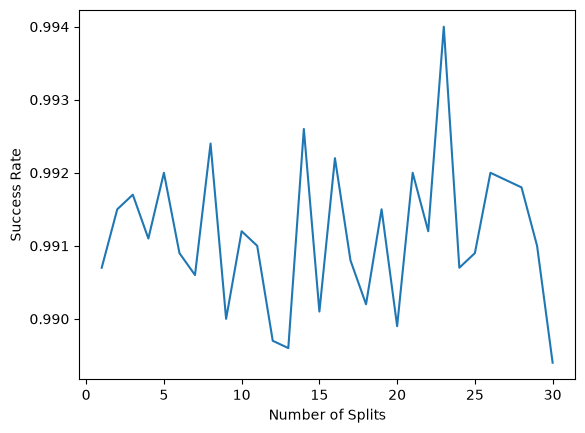

In [12]:
fig, ax = plt.subplots()
ax.plot(splitrange, success_rates)
ax.set_xlabel("Number of Splits")
ax.set_ylabel("Success Rate")

In [13]:
def kennedy_with_extra_displacement(true_sig, alpha, beta, dark_count_rate=0):
    displacement = - (alpha + beta)
    gamma = true_sig + displacement
    prob_0 = np.exp(-np.abs(gamma)**2)
    prob_0_actual = prob_0 * (1.0 - dark_count_rate)
    prob_click = 1.0 - prob_0_actual
    detector_clicked = np.random.rand() < prob_click
    if not detector_clicked:
        return "+alpha"
    elif detector_clicked:
        return "-alpha"


alpha = 0.2
beta = np.linspace(-1, 1, 100)
rounds_pr_beta = 1000
success_rates_beta = []
for b in tqdm.tqdm(beta, desc="Evaluating beta values"):
    correct_guesses = 0
    for _ in range(rounds_pr_beta):
        true_sign = np.random.choice([1, -1])
        true_signal = true_sign * alpha
        expected_result = "+alpha" if true_signal > 0 else "-alpha"
        kennedy_result = kennedy_with_extra_displacement(true_signal, alpha, b)
        if kennedy_result == expected_result:
            correct_guesses += 1
    success_rate = correct_guesses / rounds_pr_beta
    success_rates_beta.append(success_rate)

Evaluating beta values: 100%|██████████| 100/100 [00:02<00:00, 49.53it/s]


Text(0.5, 1.0, 'Success Rate vs Beta for alpha=0.2')

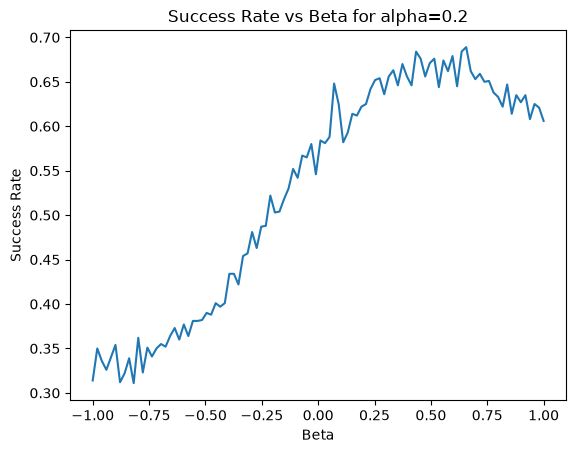

In [14]:
fig, ax = plt.subplots()
ax.plot(beta, success_rates_beta)
ax.set_xlabel("Beta")
ax.set_ylabel("Success Rate")
ax.set_title(f"Success Rate vs Beta for alpha={alpha}")

Scanning beta_0...


beta_0: 100%|██████████| 40/40 [00:01<00:00, 37.23it/s]


Scanning beta_1...


beta_1: 100%|██████████| 40/40 [00:22<00:00,  1.77it/s]


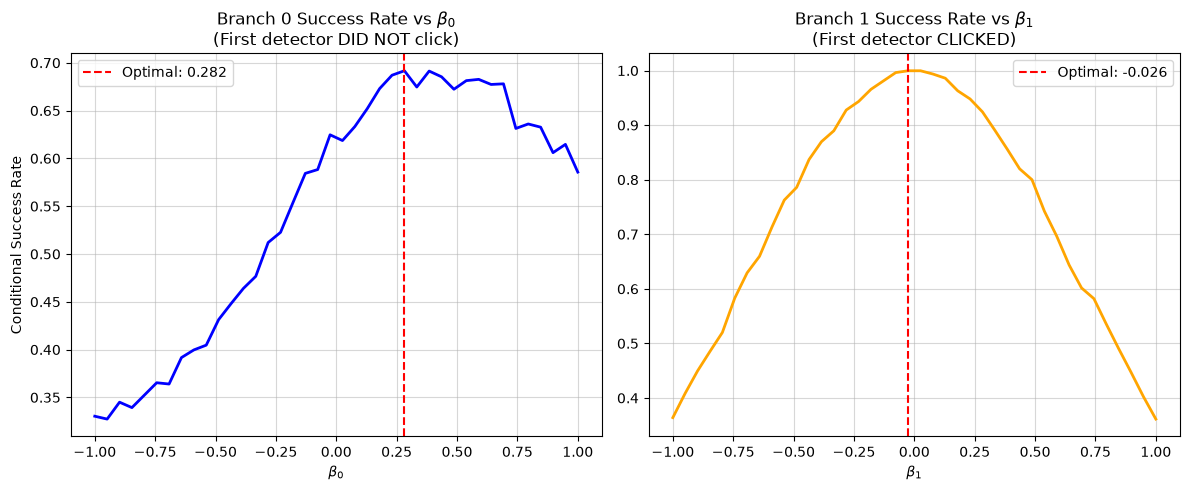

In [17]:
def evaluate_beta_0(b0, alpha, beta_init, target_valid_runs):
    """Evaluates ONLY the branch where the first detector DOES NOT click."""
    valid_runs = 0
    correct_guesses = 0
    
    while valid_runs < target_valid_runs:
        # 1. Random true signal
        true_sign = np.random.choice([1, -1])
        slice_alpha = (true_sign * alpha) / np.sqrt(2)
        ref_alpha = alpha / np.sqrt(2)
        
        # 2. Stage 1
        disp1 = -(ref_alpha + beta_init)
        gamma1 = slice_alpha + disp1
        prob_0_1 = np.exp(-np.abs(gamma1)**2)
        click1 = np.random.rand() > prob_0_1
        
        # 3. Filter for Branch 0
        if not click1:
            valid_runs += 1
            # Apply beta_0
            disp2 = -(ref_alpha + b0)
            gamma2 = slice_alpha + disp2
            prob_0_2 = np.exp(-np.abs(gamma2)**2)
            click2 = np.random.rand() > prob_0_2
            
            # If Branch 0 clicks, we flip guess from +1 to -1
            final_guess = -1 if click2 else 1
            if final_guess == true_sign:
                correct_guesses += 1
                
    return b0, correct_guesses / target_valid_runs


def evaluate_beta_1(b1, alpha, beta_init, target_valid_runs):
    """Evaluates ONLY the branch where the first detector CLICKS."""
    valid_runs = 0
    correct_guesses = 0
    
    while valid_runs < target_valid_runs:
        # 1. Random true signal
        true_sign = np.random.choice([1, -1])
        slice_alpha = (true_sign * alpha) / np.sqrt(2)
        ref_alpha = alpha / np.sqrt(2)
        
        # 2. Stage 1
        disp1 = -(ref_alpha + beta_init)
        gamma1 = slice_alpha + disp1
        prob_0_1 = np.exp(-np.abs(gamma1)**2)
        click1 = np.random.rand() > prob_0_1
        
        # 3. Filter for Branch 1
        if click1:
            valid_runs += 1
            # Apply beta_1 (Note: displacement is positive here!)
            disp2 = +(ref_alpha + b1)
            gamma2 = slice_alpha + disp2
            prob_0_2 = np.exp(-np.abs(gamma2)**2)
            click2 = np.random.rand() > prob_0_2
            
            # If Branch 1 clicks, we flip guess from -1 to +1
            final_guess = 1 if click2 else -1
            if final_guess == true_sign:
                correct_guesses += 1
                
    return b1, correct_guesses / target_valid_runs

# ==========================================
# Run the Decoupled Scans
# ==========================================

alpha = 0.3
beta_init = 0.0
beta_array = np.linspace(-1, 1, 40)
rounds_pr_beta = 3000  # High number for smooth curves!

print("Scanning beta_0...")
results_b0 = joblib.Parallel(n_jobs=-1, prefer="threads")(
    joblib.delayed(evaluate_beta_0)(b, alpha, beta_init, rounds_pr_beta)
    for b in tqdm.tqdm(beta_array, desc="beta_0")
)

print("Scanning beta_1...")
results_b1 = joblib.Parallel(n_jobs=-1, prefer="threads")(
    joblib.delayed(evaluate_beta_1)(b, alpha, beta_init, rounds_pr_beta)
    for b in tqdm.tqdm(beta_array, desc="beta_1")
)

# Unpack results
b0_vals, b0_success = zip(*results_b0)
b1_vals, b1_success = zip(*results_b1)

# ==========================================
# Plotting the Results
# ==========================================
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot Beta 0
ax[0].plot(b0_vals, b0_success, color='blue', lw=2)
opt_b0 = b0_vals[np.argmax(b0_success)]
ax[0].axvline(opt_b0, color='red', linestyle='--', label=f'Optimal: {opt_b0:.3f}')
ax[0].set_title("Branch 0 Success Rate vs $\\beta_0$\n(First detector DID NOT click)")
ax[0].set_xlabel("$\\beta_0$")
ax[0].set_ylabel("Conditional Success Rate")
ax[0].legend()
ax[0].grid(True, alpha=0.5)

# Plot Beta 1
ax[1].plot(b1_vals, b1_success, color='orange', lw=2)
opt_b1 = b1_vals[np.argmax(b1_success)]
ax[1].axvline(opt_b1, color='red', linestyle='--', label=f'Optimal: {opt_b1:.3f}')
ax[1].set_title("Branch 1 Success Rate vs $\\beta_1$\n(First detector CLICKED)")
ax[1].set_xlabel("$\\beta_1$")
ax[1].legend()
ax[1].grid(True, alpha=0.5)

plt.tight_layout()
plt.show()